### Jonathan Steen
### MSDS, Bellevue University
### DSC 630: Predictive Analytics
### Instructor: Frank Neugebauer
### May 4th, 2025
### 8.2 Assignment: Time Series Modeling

## Set Imports, Load Data and Initial Exploration

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from math import sqrt
from prophet import Prophet

# Load the retail sales data
df = pd.read_csv('us_retail_sales.csv')
df.head()

,YEAR,JAN,FEB,MAR,APR,MAY,JUN,JUL,AUG,SEP,OCT,NOV,DEC
0,1992,146925,147223,146805,148032,149010,149800,150761.0,151067.0,152588.0,153521.0,153583.0,155614.0
1,1993,157555,156266,154752,158979,160605,160127,162816.0,162506.0,163258.0,164685.0,166594.0,168161.0
2,1994,167518,169649,172766,173106,172329,174241,174781.0,177295.0,178787.0,180561.0,180703.0,181524.0
3,1995,182413,179488,181013,181686,183536,186081,185431.0,186806.0,187366.0,186565.0,189055.0,190774.0
4,1996,189135,192266,194029,194744,196205,196136,196187.0,196218.0,198859.0,200509.0,200174.0,201284.0


## Preprocessing: Reshaping the Data

In [2]:
# Convert wide-format data (columns as months) to long-format
df_long = df.melt(id_vars=["YEAR"], var_name="MONTH", value_name="SALES")

# Create a datetime column from YEAR and MONTH
df_long["DATE"] = pd.to_datetime(df_long["YEAR"].astype(str) + df_long["MONTH"], format="%Y%b")

# Drop rows with missing values
df_long = df_long.dropna(subset=["SALES"])

# Sort by date
df_long = df_long.sort_values("DATE").reset_index(drop=True)

df_long.head()

,YEAR,MONTH,SALES,DATE
0,1992,JAN,146925.0,1992-01-01
1,1992,FEB,147223.0,1992-02-01
2,1992,MAR,146805.0,1992-03-01
3,1992,APR,148032.0,1992-04-01
4,1992,MAY,149010.0,1992-05-01


#### **Rationale**: I reshaped the data so each row shows one month’s sales. This makes it easier to plot, work with dates, and build models.

### Step 1: Plotting the Data

#### **Observation**: We should see an upward trend over time with some seasonality patterns, especially near year-end holidays.

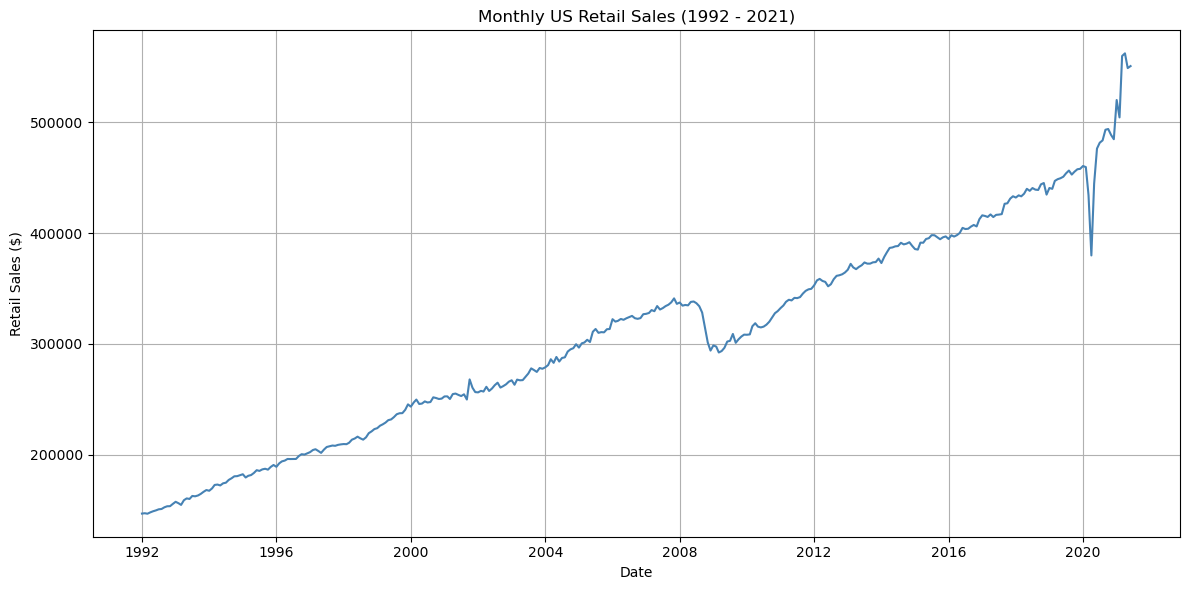

In [3]:
# Plot the monthly retail sales over time to understand trends and seasonality
plt.figure(figsize=(12, 6))
plt.plot(df_long["DATE"], df_long["SALES"], label='Monthly Retail Sales', color='steelblue')
plt.title("Monthly US Retail Sales (1992 - 2021)")
plt.xlabel("Date")
plt.ylabel("Retail Sales ($)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Step 2: Build a Predictive Model (Prophet Modeling)

In [4]:
# Prophet requires columns named 'ds' and 'y'
from prophet import Prophet

# Rename columns
prophet_df = df_long[["DATE", "SALES"]].rename(columns={"DATE": "ds", "SALES": "y"})

# Split the data for Prophet: use all months before July 2020 for training, and July 2020–June 2021 for testing
train_df = prophet_df[prophet_df["ds"] < "2020-07-01"].copy()
test_df = prophet_df[prophet_df["ds"] >= "2020-07-01"].copy()

# Initialize and fit the model
model = Prophet()
model.fit(train_df)

10:10:39 - cmdstanpy - INFO - Chain [1] start processing
10:10:39 - cmdstanpy - INFO - Chain [1] done processing


### Step 3: Forecast the next 12 months (monthly frequency)

In [5]:
# Create future monthly dates (12 periods) and generate sales forecasts
future = model.make_future_dataframe(periods=12, freq='MS')
forecast = model.predict(future)

### Step 4: Plot the forecast

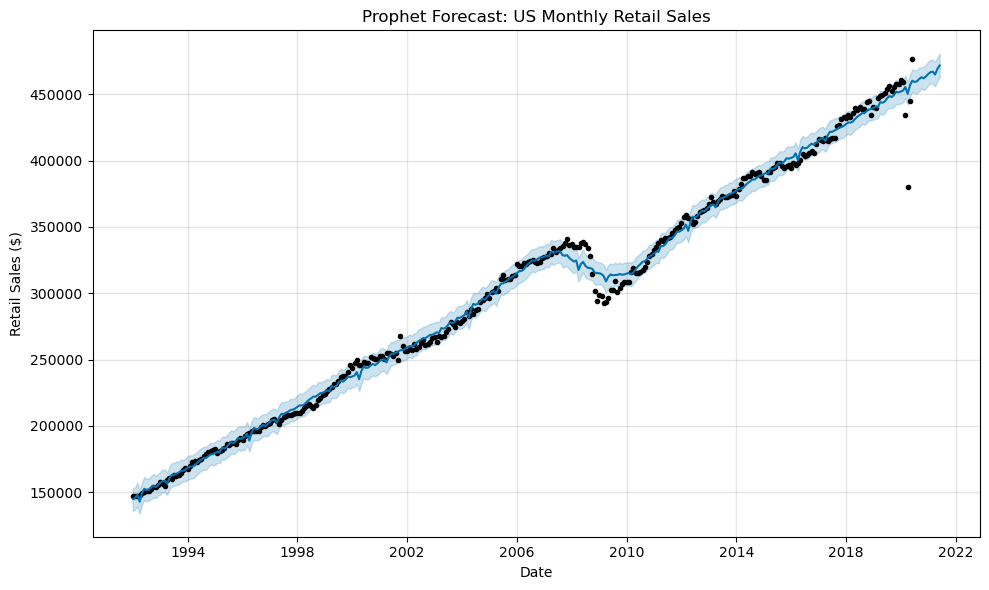

In [6]:
# Plot the full forecast including historical and predicted retail sales
fig1 = model.plot(forecast)
plt.title("Prophet Forecast: US Monthly Retail Sales")
plt.xlabel("Date")
plt.ylabel("Retail Sales ($)")
plt.tight_layout()
plt.show()

### Step 5: Evaluate model performance on the test set

In [7]:
# Merge actual and predicted values for the test set and calculate RMSE
merged = test_df.merge(forecast[["ds", "yhat"]], on="ds", how="left")
rmse_prophet = sqrt(mean_squared_error(merged["y"], merged["yhat"]))
print(f"Prophet RMSE on test set: ${rmse_prophet:,.2f}")

Prophet RMSE on test set: $57,238.51


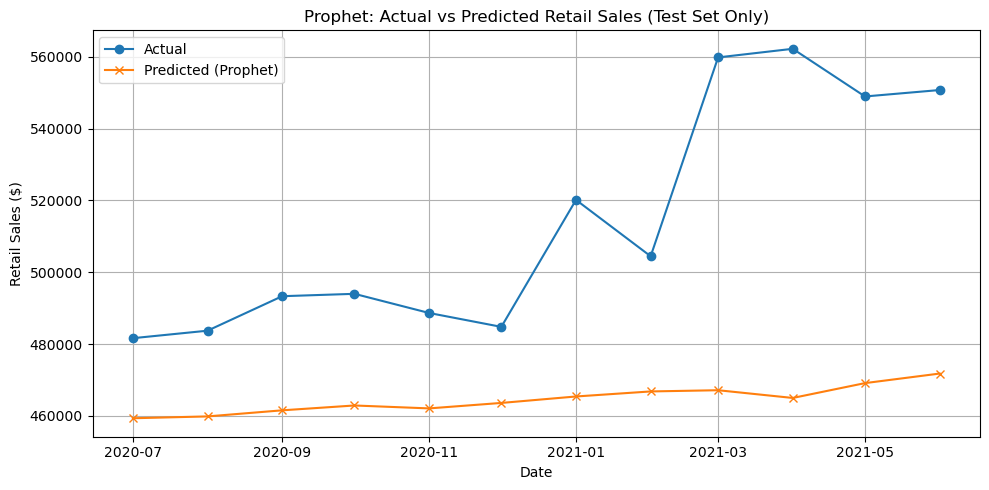

In [8]:
# Plot actual vs predicted for test period only
plt.figure(figsize=(10, 5))
plt.plot(merged["ds"], merged["y"], label="Actual", marker='o')
plt.plot(merged["ds"], merged["yhat"], label="Predicted (Prophet)", marker='x')
plt.title("Prophet: Actual vs Predicted Retail Sales (Test Set Only)")
plt.xlabel("Date")
plt.ylabel("Retail Sales ($)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

#### **Thoughts**: This plot compares Prophet’s predictions to the actual retail sales for the test period (July 2020 – June 2021). It helps visually assess how well the model captured trends and seasonal changes during the forecast window.

## Conclusion

In this assignment, I tested two ways to forecast monthly retail sales. I started with a Random Forest model using time-based features. It picked up some seasonality but missed major changes in the trend and gave mostly flat predictions, with an RMSE around $71,000.

Next, I used Facebook Prophet, which is built for time series data. It did a better job of capturing the overall trend, even though it underpredicted the spike in early 2021. Prophet's RMSE was lower, about $57,000, making it the better option here.

If I were to keep improving this, I’d look into adding holidays or other outside factors to help explain changes in sales more clearly.